# MESSAGEix-Pakistan 
### Baseline Model
In this notebook, we are reading data and building baseline scenerio.

<img src="https://wit.lums.edu.pk/sites/default/files/inline-images/WIT_Banner.jpg" alt="Girl in a jacket" width="850" height="250">

In [1]:
# fundamental libraries
import os
import pandas as pd
import numpy as np
import ixmp
import message_ix
from message_ix import log


# for reporting and visualization
from modelFiles.plotter import plotter_MSG

# script functions
from modelFiles.utils import *
from modelFiles.adjust_capacity import adjust_capacity
from modelFiles.national_ev_policy import ev_shares
from modelFiles.adjust_transport import adjust_transport
from modelFiles.elec_gen_shares import generation_shares
from modelFiles.add_fuel_prices import add_fuel_prices
from modelFiles.update_calibration import model_calibrate
from modelFiles.adjust_activity import adjust_activity


# autoreload modules when changes are applied to them
%load_ext autoreload 
%autoreload all
%reload_ext autoreload
%matplotlib inline

In [2]:
# saving current working directory path for later repeated use
cwd_path = os.getcwd()

Create scenario

In [3]:
# creating ixmp platform object
new_mp = ixmp.Platform("committed 6.0")

# creating a new, empty scenario object
scenario = message_ix.Scenario(
    new_mp, model="COMMITTED", scenario="baseline", version="new"
)

Read Data

In [4]:
# loading data (sets & parameters) into our model - latest data file is MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx
data_path = "./modelData/MESSAGEix_Pakistan_SSP2_V2.2_Baseline.xlsx"
scenario.read_excel(data_path, add_units=True, commit_steps=False, init_items=True,)

In [5]:
scenario = scenario.clone(scenario.model, "baseline", keep_solution=False, shift_first_model_year=2025)

In [6]:
# keep the model's temporal scope till 2070 only
modify_last_year(scenario, 2070)

In [7]:
tecs = ["loil_imp", "oil_imp", "coal_imp"]
insert_history(scenario, 2020, tecs)


In [8]:
# capacity
# adjust_capacity(scenario)

In [8]:
adjust_activity(scenario)

In [9]:
calibrate_solar(scenario)

In [10]:
adjust_transport(scenario)

In [13]:
# # list of technologies outputing on the demand level
# tec_list = list(set((scenario.par(
#                 'output', {'level': 'useful',
#                         'commodity': 'i_therm'}))['technology']))

In [14]:
# print(tec_list)

In [15]:
# scenario.remove_solution()

In [ ]:
# scenario.check_out()

In [11]:
ev_shares(scenario)

In [12]:
generation_shares(scenario)

In [ ]:
scenario.remove_set("technology", {"technology":"igcc"})

at.ac.iiasa.ixmp.exceptions.IxException: at.ac.iiasa.ixmp.exceptions.IxException: The element has the wrong number of index dimensions for index set 'technology' (dim=0) !

In [27]:
scenario.set("cat_tec", {"type_tec":["powerplant_low-carbon", "powerplant_fossil", "powerplant_hydro"]})

,type_tec,technology
0,powerplant_fossil,coal_adv
1,powerplant_fossil,coal_adv_ccs
2,powerplant_fossil,coal_ppl
3,powerplant_fossil,coal_ppl_u
4,powerplant_fossil,foil_ppl
...,...,...
66,powerplant_low-carbon,csp_sm1_res_hist_2020
67,powerplant_low-carbon,csp_sm1_res_hist_2010
68,powerplant_fossil,igcc
69,powerplant_hydro,hydro_lc


In [ ]:
# model_calibrate(scenario, nodeNames=["R12_PAK"], replace_negative=False)

##### Solve the Model

In [26]:
log.info(f"version number before commit(): {scenario.version}")

# commit the model structure and input data (sets and parameters)
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

# exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

# solve model
scenario.solve(case=caseName)

scenario.var("OBJ")["lvl"]

ModelError: GAMS errored with return code 3:
    There was an execution error

For details, see the terminal output above, plus:
Listing   : d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\MESSAGE_run.lst
Log file  : d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\MESSAGE_run.log
Input data: d:\COMMITTED\venv-committed\Lib\site-packages\message_ix\model\data\MsgData_COMMITTED__baseline__v20.gdx

##### Reporting Results

In [ ]:
from modelFiles.report.iamc_report_hackathon import report
from datetime import datetime
import time
timestamp = f"{str(datetime.now().strftime('%Y-%m-%d--%H-%M'))}"
start = time.time()
df, path_name= report(mp=new_mp, scen=scenario, out_dir="./output/reporting_outputs", out_file_timestamp = timestamp, IDEA_format=False)
end = time.time()

processing Table: Resource|Extraction
processing Table: Resource|Cumulative Extraction
processing Table: Primary Energy
PostProcess.out() got an unexpected keyword argument 'inpfilter'
processing Table: Primary Energy (substitution method)
PostProcess.out() got an unexpected keyword argument 'inpfilter'
processing Table: Final Energy


KeyboardInterrupt: 

In [ ]:
# print(path_name)

##### Plotting Results

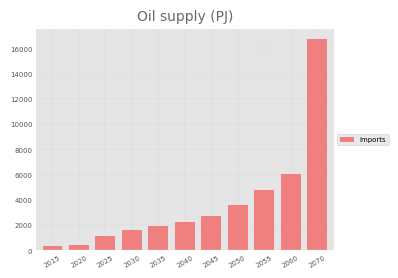

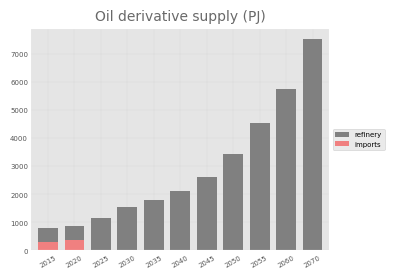

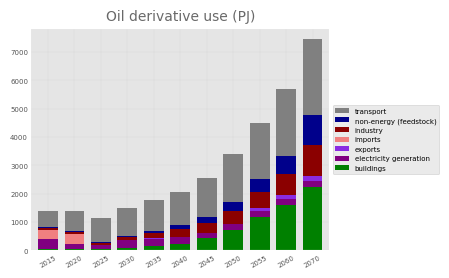

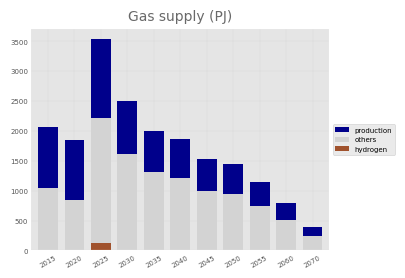

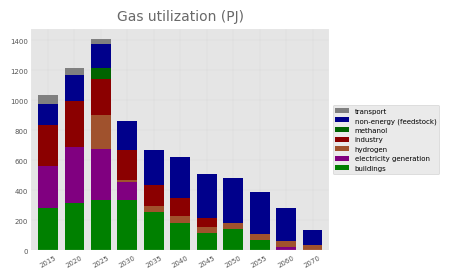

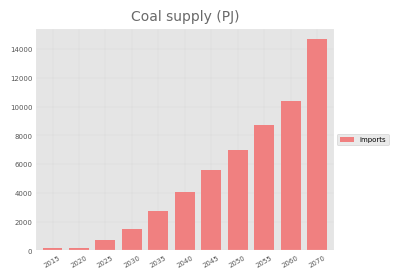

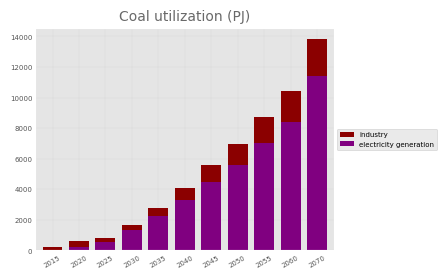

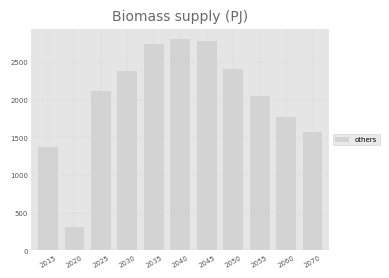

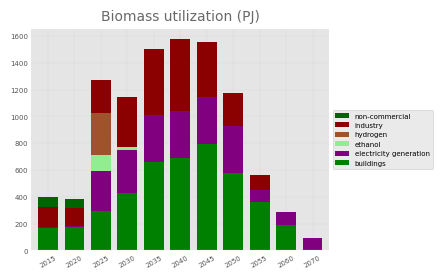

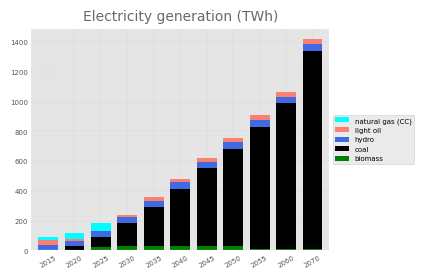

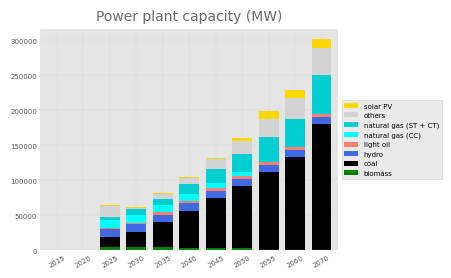

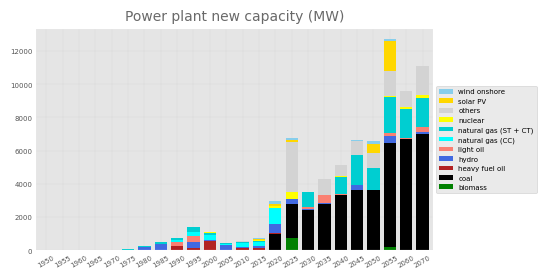

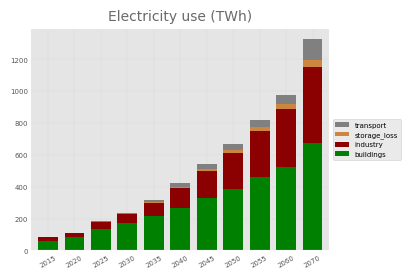

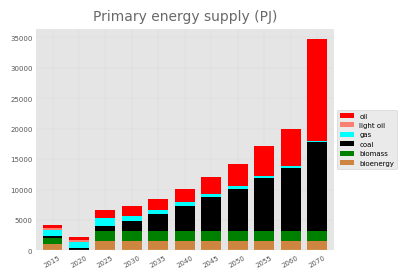

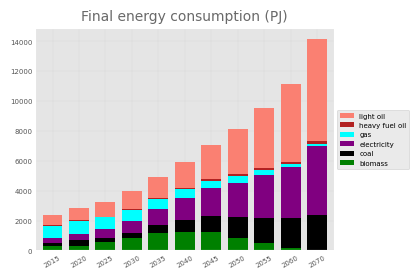

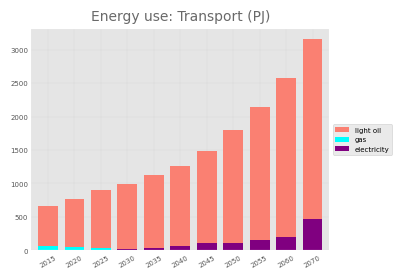

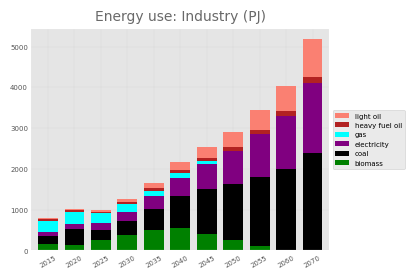

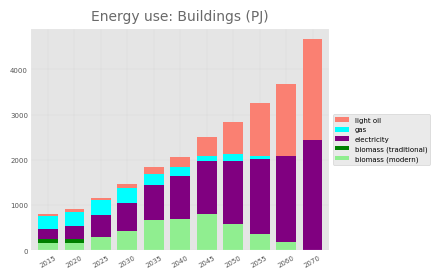

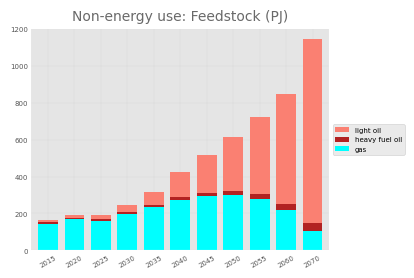

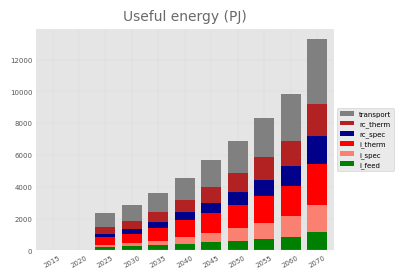

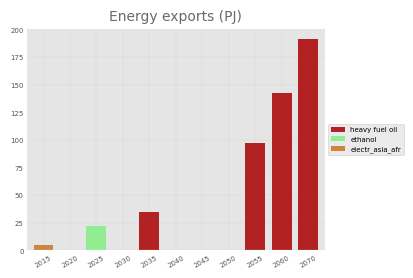

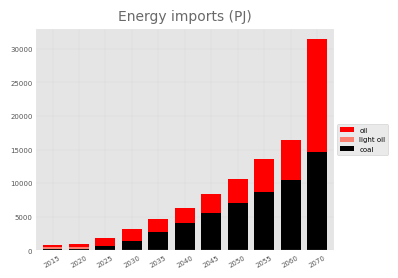

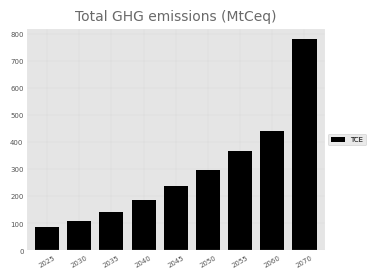

{'Electricity generation (TWh)':         biomass         coal      hydro  light oil  natural gas (CC)
 2015   0.556260     0.148044  34.632660  35.362368         22.428041
 2020   0.711312    27.549324  33.548172  17.195880         36.731689
 2025  24.638720    66.673793  40.371559   0.000000         51.166278
 2030  26.876500   154.312492  43.056509  14.375057          0.000000
 2035  29.094101   259.206923  44.252498  22.998216          0.000000
 2040  29.246972   382.822641  44.432006  26.182939          0.000000
 2045  29.246972   521.913759  44.432006  26.182939          0.000000
 2050  29.246972   653.641266  44.432006  26.182939          0.000000
 2055   7.614312   822.336361  44.432006  32.213204          0.000000
 2060   7.614312   981.951154  44.432006  29.565805          0.000000
 2070   7.614312  1334.965259  44.432006  32.213204          0.000000,
 'Power plant capacity (MW)':           biomass           coal         hydro    light oil  natural gas (CC)  \
 2015     0.0000

In [ ]:
path = os.path.join(cwd_path, "output/plots")
plotter = plotter_MSG(scenario)
plotter.plotter(caseName, nodeloc=["R12_PAK"], path=path, yr_min=2015, yr_max=2070)

In [ ]:
# close the connection to the database
new_mp.close_db() 

In [ ]:
new_mp.open_db()